# Graph Exploratory Data Analysis

This notebook covers the graph exploratory data analysis of the graph data. For the tabular exploratory data analysis, see the `01_eda.ipynb` notebook.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from collections import defaultdict

import networkx as nx
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib import pyplot as plt

from anomaly_detector.data_commons import (
    decorate_edges_with_node_types,
    load_figraph_data,
    merge_df_dict,
    order_edge_nodes,
)
from anomaly_detector.eda_utils import (
    ccdf_plot,
    cdf_plot,
    compute_homophily_scores,
    draw_count_bar_plot,
    draw_stacked_count_bar_plot,
)
from anomaly_detector.graph.nx_graph import build_networkx_graph

pd.options.display.max_colwidth = 650

/home/mario/workspace/financial_anomaly_detection/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Load Data

In [3]:
TRAIN_YEARS = range(2014, 2020 + 1)

train_tabular_dict, train_edges_dict = load_figraph_data(TRAIN_YEARS)

train_tabular = merge_df_dict(train_tabular_dict)
train_edges = merge_df_dict(train_edges_dict)

train_edges.head(3)

,id_1,id_2,type,year
0,U175010,L000801,Related-party transaction,2014
1,U180818,L002057,Related-party transaction,2014
2,H34660,L002588,Investment,2014


# Basic Hygiene

## Node and Edge Types

In [4]:
# Decorate edges with node types
train_edges = decorate_edges_with_node_types(train_edges)

In [5]:
unique_node_types = pd.concat(
    [train_edges["node_type_1"], train_edges["node_type_2"]],
).unique()

display(f"Unique node types: {unique_node_types}")
display(f"Unique edge types: {train_edges['type'].unique()}")

"Unique node types: ['U' 'H' 'L' 'O' 'A']"

"Unique edge types: ['Related-party transaction' 'Investment' 'Audit' 'Supply chain']"

There are **5** node types in the dataset, which are represented by the first character of the `node ID`.
The node types are:
* **U** - Unlisted Company
* **H** - Human
* **L** - Listed Company
* **O** - Other (e.g., government agency, school)
* **A** - Audit Institution

There are **4** edge types in the dataset, which are represented by the `type` column in the edge data:
* **Related-party transaction**
* **Investment**
* **Audit**
* **Supply chain**

## Self loops

In [6]:
train_edges.loc[lambda x: x["id_1"] == x["id_2"]].shape[0]

0

There are no self loops in the training data.

## Edge Node Ordering

In [7]:
display(
    train_edges[["node_type_1", "node_type_2", "type"]]
    .drop_duplicates()
    .sort_values(by=["type"]),
)

,node_type_1,node_type_2,type
59,L,A,Audit
5083,A,L,Audit
2,H,L,Investment
10,U,L,Investment
12,L,L,Investment
321,O,L,Investment
37,L,U,Investment
38,L,H,Investment
204,L,O,Investment
3141,L,O,Related-party transaction


Since the graph is undirected, edge direction carries no meaning - but the node ordering within each edge entry isn't guaranteed to follow any consistent convention.

In [8]:
train_edges = order_edge_nodes(train_edges)

## Node Types by Edge Type
Each edge type connects only a specific set of node type pairs. Since the listed company is always in the
first position, the breakdown below reads as "what a listed company is connected to" for each edge type.

In [9]:
train_edges[["type", "node_type_1", "node_type_2"]].drop_duplicates().sort_values(
    by=["type", "node_type_1", "node_type_2"],
)

,type,node_type_1,node_type_2
59,Audit,L,A
2,Investment,L,H
12,Investment,L,L
204,Investment,L,O
10,Investment,L,U
94,Related-party transaction,L,H
13,Related-party transaction,L,L
3141,Related-party transaction,L,O
0,Related-party transaction,L,U
1790,Supply chain,L,L


**Audit** edges link a Listed Company (**L**) and an Audit Institution (**A**).

**Investment** edges link the following node types:
* **L <-> U** - Listed Company and Unlisted Company
* **L <-> H** - Listed Company and Human
* **L <-> L** - Listed Company and Listed Company
* **L <-> O** - Listed Company and Other

**Related-party-transaction** edges span the same four pairs.

**Supply chain** only connect Listed Companies to other Listed Companies.

## Parallel Edges

In [10]:
train_edges[["id_1", "id_2", "year"]].duplicated().sum()

np.int64(0)

The graph contains no parallel edges: each pair of nodes is connected at most once, so a given pair doesn't appear twice even under different edge types within the same year.

## Reccurring Edges Across Years

In [11]:
display(
    f"Number of duplicate edges: {train_edges[['id_1', 'id_2', 'type']].duplicated().sum()}",
)

display("Some of the edges in the training data reoccur across multiple years.")
display(train_edges[["id_1", "id_2", "type"]].value_counts().to_frame("count").head(10))

'Number of duplicate edges: 402820'

'Some of the edges in the training data reoccur across multiple years.'

count
id_1    id_2    type                            
L000001 H2      Related-party transaction      7
L300294 U175415 Investment                     7
L300295 H32756  Investment                     7
L000001 A107374 Audit                          7
L002386 U176945 Related-party transaction      7
        U201002 Related-party transaction      7
L601989 U77340  Related-party transaction      7
        U77001  Related-party transaction      7
L000639 H553    Related-party transaction      7
L300071 H982    Related-party transaction      7

Some of the edges in the training data reoccur across multiple years.

## Listed Company Coverage

In [12]:
comp_coverage_data = []
for year in TRAIN_YEARS:
    tabular_companies_set = set(
        train_tabular.loc[lambda x, y=year: x["Year"] == y, "nodeID"],
    )

    edges_in_year = train_edges.loc[lambda x, y=year: x["year"] == y]
    edge_companies_set = set(
        edges_in_year.loc[lambda x: x["node_type_1"] == "L", "id_1"],
    ).union(set(edges_in_year.loc[lambda x: x["node_type_2"] == "L", "id_2"]))

    comp_coverage_data.append(
        {
            "year": year,
            "tabular_companies_n": len(tabular_companies_set),
            "edge_companies_n": len(edge_companies_set),
            "not_in_edges_n": len(tabular_companies_set.difference(edge_companies_set)),
            "not_in_tabular_n": len(
                edge_companies_set.difference(tabular_companies_set),
            ),
        },
    )


comp_coverage_df = pd.DataFrame(comp_coverage_data)
display(comp_coverage_df)

,year,tabular_companies_n,edge_companies_n,not_in_edges_n,not_in_tabular_n
0,2014,2631,2631,0,0
1,2015,2824,2824,0,0
2,2016,3125,3125,0,0
3,2017,3503,3503,0,0
4,2018,3596,3596,0,0
5,2019,3815,3815,0,0
6,2020,4269,4269,0,0


The two sources agree on the set of listed companies: every company in the tabular data (`train_companies`) appears as an **L** node in the edge list (`train_edges`), and vice versa

## Conclusion
The graph is undirected, contains no self-loops, and has no duplicate edges within a given year, though some edges recur across multiple years.

It is a heterogeneous graph with five node types and four edge types, where each edge type connects only a specific set of node-type pairs.

The order of nodes within an edge entry does not follow any semantic convention; nodes are instead sorted by type and then by ID for ease of processing.

Finally, the tabular and graph data are fully consistent: every company in the tabular data has at least one edge in the graph, and every company in the graph has a corresponding tabular entry.

# Basic Graph Properties

In [13]:
nx_graphs = {
    year: build_networkx_graph(
        train_tabular.loc[lambda x, y=year: x["Year"] == y],
        train_edges.loc[lambda x, y=year: x["year"] == y],
    )
    for year in TRAIN_YEARS
}

In [14]:
graph_data = defaultdict(dict)


def graph_degrees_array(graph):
    return np.array([degree for _, degree in graph.degree()], dtype=np.float64)


for year, graph in nx_graphs.items():
    degrees = graph_degrees_array(graph)

    graph_data[year]["num_nodes"] = graph.number_of_nodes()
    graph_data[year]["num_edges"] = graph.number_of_edges()
    graph_data[year]["connected"] = nx.is_connected(graph)
    graph_data[year]["density"] = nx.density(graph)
    graph_data[year]["avg_degree"] = degrees.mean()
    graph_data[year]["diameter"] = nx.diameter(graph, usebounds=True)
    graph_data[year]["avg_clustering"] = nx.average_clustering(graph)


pd.DataFrame.from_dict(graph_data, orient="index").sort_index()

,num_nodes,num_edges,connected,density,avg_degree,diameter,avg_clustering
2014,53678,79958,True,0.000056,2.979172,8,0.024034
2015,58174,91450,True,0.000054,3.144016,8,0.023395
2016,65045,94784,True,0.000045,2.914413,8,0.024847
2017,75818,105963,True,0.000037,2.795194,8,0.025281
2018,80839,109852,True,0.000034,2.717797,8,0.027224
2019,86533,118878,True,0.000032,2.747576,8,0.028021
2020,97386,135814,True,0.000029,2.789189,8,0.030022


The graph grows steadily over the training period: from $53\,678$ nodes and $79\,958$ edges in 2014 to $80\,839$ nodes and $109\,852$ edges in 2018.

In every year the graph is **connected** and extremely **sparse**, with the density decreasing from $5.6 \times 10^{-5}$ in 2014 to $3.4 \times 10^{-5}$ in 2018, and a diameter of **8** throughout.

The average clustering coefficient is low, ranging from $0.02$ to $0.03$, and the average degree is also low, ranging from $2.71$ to $3.14$.

# Nodes

In [15]:
lst = []
for year, graph in nx_graphs.items():
    for node_id, node_attrs in graph.nodes(data=True):
        lst.append(
            {
                "year": year,
                "node": node_id,
                "type": node_attrs["type"],
                "degree": graph.degree(node_id),
                "label": node_attrs.get("label", None),
            },
        )

nodes_df = pd.DataFrame(lst)
nodes_df.head(3)

,year,node,type,degree,label
0,2014,L000001,L,100,0.0
1,2014,L000002,L,34,0.0
2,2014,L000004,L,31,0.0


## Nodes per Year

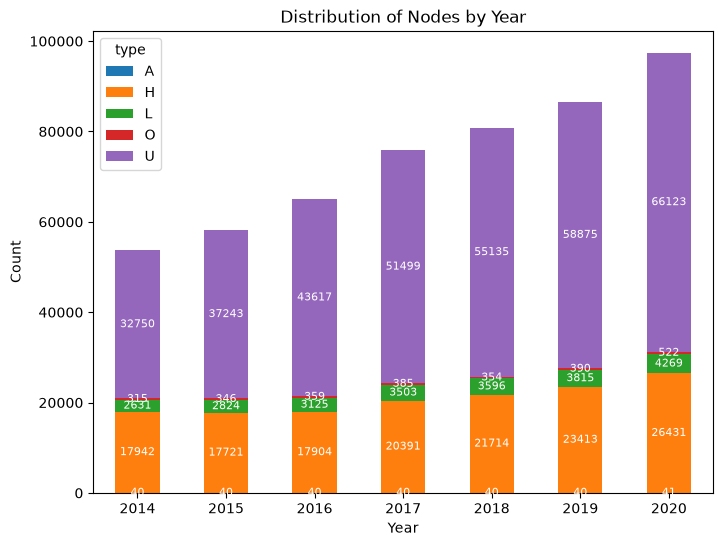

In [16]:
node_type_year_count = (
    nodes_df.value_counts(subset=["year", "type"]).unstack("type").sort_index()
)

draw_stacked_count_bar_plot(
    node_type_year_count,
    label="count",
    title="Distribution of Nodes by Year",
    xlabel="Year",
    ylabel="Count",
)

## Node Degrees
### By Node Type

In [17]:
nodes_df.groupby(["type"])["degree"].describe()

,count,mean,std,min,25%,50%,75%,max
type,,,,,,,,
A,281.0,84.270463,112.328209,2.0,26.0,39.0,87.0,580.0
H,145516.0,1.400032,19.751177,1.0,1.0,1.0,1.0,3923.0
L,23763.0,33.549468,41.008885,1.0,20.0,26.0,36.0,1584.0
O,2671.0,5.149757,11.663094,1.0,1.0,1.0,2.0,100.0
U,345242.0,1.259986,5.651107,1.0,1.0,1.0,1.0,1251.0


Most of the **H**, **O** and **U** nodes have a degree of 1.

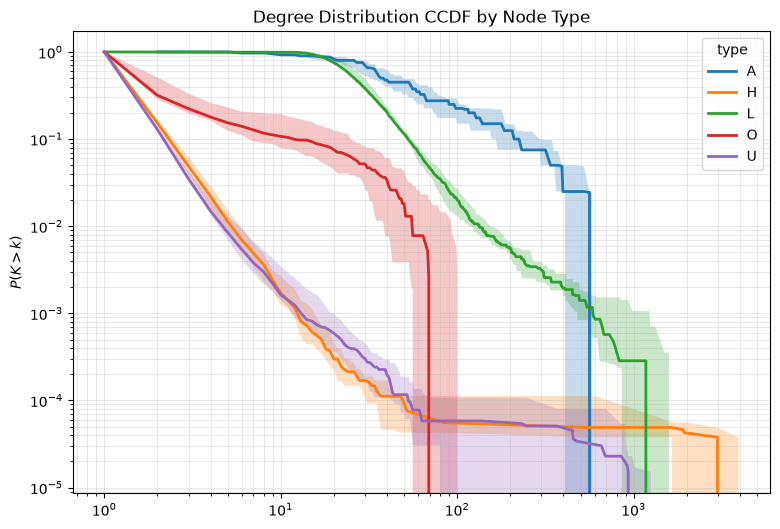

In [18]:
ax = ccdf_plot(nodes_df, group_by="type", column="degree")
ax.set_title("Degree Distribution CCDF by Node Type")
plt.show()

In [19]:
def year_range(s: pd.Series, fmt: str = "{:.0f}") -> str:
    lo, hi = s.min(), s.max()
    return fmt.format(lo) if lo == hi else f"{fmt.format(lo)} - {fmt.format(hi)}"


per_type_year = nodes_df.groupby(["type", "year"])["degree"].agg(
    n="size",
    deg1_pct=lambda x: (x == 1).mean() * 100,
    median="median",
    p99=lambda x: x.quantile(0.99),
    max="max",
)

per_type_year.groupby("type").agg(
    nodes_per_year=("n", year_range),
    deg1_pct=("deg1_pct", lambda s: year_range(s, "{:.1f}")),
    median=("median", year_range),
    p99=("p99", year_range),
    max=("max", year_range),
)

,nodes_per_year,deg1_pct,median,p99,max
type,,,,,
A,40 - 41,0.0,32 - 49,387 - 557,408 - 580
H,17721 - 26431,83.2 - 86.1,1,4 - 5,1649 - 3923
L,2631 - 4269,0.0 - 0.3,25 - 29,116 - 153,855 - 1584
O,315 - 522,48.9 - 71.5,1 - 2,37 - 89,56 - 100
U,32750 - 66123,86.3 - 88.1,1,4 - 5,80 - 1251


Connectivity differs markedly by node type: **A** ($M_d \in [32, 40]$) and **L** ($M_d \in [25, 29]$) nodes carry by far the most edges, while **O** ($M_d \in [1, 2]$), **H** ($M_d = 1$), and **U** ($M_d = 1$) nodes are only sparsely connected.

### By Fraud Label

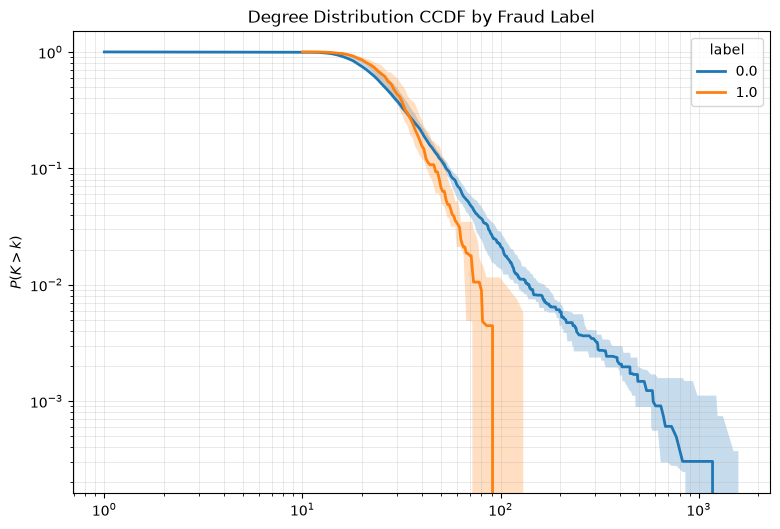

In [20]:
ax = ccdf_plot(nodes_df[lambda x: x["type"] == "L"], group_by="label", column="degree")
ax.set_title("Degree Distribution CCDF by Fraud Label")
plt.show()

In [21]:
nodes_df.loc[lambda x: x["type"] == "L"].groupby(["year", "label"])["degree"].agg(
    n="size",
    deg1_pct=lambda x: (x == 1).mean() * 100,
    median="median",
    p99=lambda x: x.quantile(0.99),
    max="max",
).groupby("label").agg(
    nodes_per_year=("n", year_range),
    deg1_pct=("deg1_pct", lambda s: year_range(s, "{:.1f}")),
    median=("median", year_range),
    p99=("p99", year_range),
    max=("max", year_range),
)

,nodes_per_year,deg1_pct,median,p99,max
label,,,,,
0.0,2536 - 4062,0.0 - 0.3,25 - 29,120 - 162,855 - 1584
1.0,95 - 225,0.0,26 - 32,65 - 84,72 - 130


The node degree distribution in every year is similar for both fraudulent and non-fraudulent companies, with slightly higher median degree for fraudulent companies than for non-fraudulent companies.

## Leafs and Non-leafs

In [22]:
nodes_df.groupby(["type"]).agg(
    leafs_n=("degree", lambda x: (x == 1).sum()),
    non_leafs_n=("degree", lambda x: (x > 1).sum()),
    leaf_pct=("degree", lambda x: (x == 1).mean() * 100),
    non_leaft_pct=("degree", lambda x: (x > 1).mean() * 100),
    non_leaf_median_degree=("degree", lambda x: x[x > 1].median()),
)

,leafs_n,non_leafs_n,leaf_pct,non_leaft_pct,non_leaf_median_degree
type,,,,,
A,0,281,0.000000,100.000000,39.0
H,123307,22209,84.737761,15.262239,2.0
L,39,23724,0.164121,99.835879,26.0
O,1766,905,66.117559,33.882441,4.0
U,300821,44421,87.133373,12.866627,2.0


**Auditors** are not leafs, 85% of **Humans**, 64% of **Others** and 87% of **Unlisted Companies** are leafs.
There are only **20** companies (through all years) that are leafs.

The leafs will be removed from the graph used for GNN training, since they can't help with message passing and will only incrase model complexity.

## Hubs

In [23]:
min_hub_degree = nodes_df["degree"].quantile(0.99)

print(f"Min hub degree: {min_hub_degree}")

display(
    nodes_df.groupby(["type"]).agg(
        hubs_n=("degree", lambda x: (x > min_hub_degree).sum()),
        total=("degree", "size"),
        hubs_pct=("degree", lambda x: (x > min_hub_degree).mean() * 100),
    ),
)

Min hub degree: 39.0


,hubs_n,total,hubs_pct
type,,,
A,140,281,49.822064
H,15,145516,0.010308
L,4829,23763,20.321508
O,83,2671,3.107450
U,60,345242,0.017379


We define a hub as an node having degree bigger than the 99th percentile of the degree distribution.
**Audit** nodes are biggest hubs followed by **Listed Companies**.

## Fraud in Company Neighborhood


At distance 2 the neighborhood spans nearly all companies, so both distance-2 features are effectively population averages rather than local measurements so only distance 1 are calculated.

In [24]:
from tqdm import tqdm

nodes_df["n_nb_fraud"] = np.nan
nodes_df["n_nb_L"] = np.nan
nodes_df["n_nb_H"] = np.nan
nodes_df["n_nb_A"] = np.nan
nodes_df["n_nb_U"] = np.nan
nodes_df["n_nb_O"] = np.nan


for row in tqdm(nodes_df.loc[lambda x: x["type"] == "L"].itertuples()):
    graph = nx_graphs[row.year]
    neighbors = list(graph.neighbors(row.node))

    nb_dict = defaultdict(int)
    for target_node in neighbors:
        nb_dict[graph.nodes[target_node]["type"]] += 1
        if (
            graph.nodes[target_node]["type"] == "L"
            and graph.nodes[target_node].get("label") == 1
        ):
            nb_dict["fraud"] += 1

    for key, value in nb_dict.items():
        nodes_df.loc[
            row.Index,
            f"n_nb_{key}",
        ] = value

nodes_df.head(3)

23763it [00:08, 2779.91it/s]


,year,node,type,degree,label,n_nb_fraud,n_nb_L,n_nb_H,n_nb_A,n_nb_U,n_nb_O
0,2014,L000001,L,100,0.0,2.0,91.0,3.0,1.0,3.0,2.0
1,2014,L000002,L,34,0.0,NaN,12.0,2.0,1.0,18.0,1.0
2,2014,L000004,L,31,0.0,NaN,5.0,12.0,1.0,12.0,1.0


### Binary Presence in Neighborhood

In [25]:
nodes_df["has_fraud_nb"] = nodes_df["n_nb_fraud"] > 0
nodes_df["has_listed_nb"] = nodes_df["n_nb_L"] > 0
nodes_df["has_human_nb"] = nodes_df["n_nb_H"] > 0
nodes_df["has_auditor_nb"] = nodes_df["n_nb_A"] > 0
nodes_df["has_unlisted_nb"] = nodes_df["n_nb_U"] > 0
nodes_df["has_other_nb"] = nodes_df["n_nb_O"] > 0


df = (
    nodes_df.loc[lambda x: x["type"] == "L"]
    .groupby(["year", "label"])
    .agg(
        n=("has_fraud_nb", "size"),
        has_fraud_nb=("has_fraud_nb", "mean"),
        has_listed_nb=("has_listed_nb", "mean"),
        has_human_nb=("has_human_nb", "mean"),
        has_auditor_nb=("has_auditor_nb", "mean"),
        has_unlisted_nb=("has_unlisted_nb", "mean"),
        has_other_nb=("has_other_nb", "mean"),
    )
    .unstack("label")
).assign(
    has_fraud_nb_diff=lambda x: x["has_fraud_nb"][1] / x["has_fraud_nb"][0],
    has_listed_nb_diff=lambda x: x["has_listed_nb"][1] / x["has_listed_nb"][0],
    has_human_nb_diff=lambda x: x["has_human_nb"][1] / x["has_human_nb"][0],
    has_auditor_nb_diff=lambda x: x["has_auditor_nb"][1] / x["has_auditor_nb"][0],
    has_unlisted_nb_diff=lambda x: x["has_unlisted_nb"][1] / x["has_unlisted_nb"][0],
    has_other_nb_diff=lambda x: x["has_other_nb"][1] / x["has_other_nb"][0],
)

df

n      has_fraud_nb           has_listed_nb           has_human_nb  \
label   0.0  1.0          0.0       1.0           0.0       1.0          0.0   
year                                                                           
2014   2536   95     0.038249  0.042105      0.906151  0.926316     0.986199   
2015   2690  134     0.061338  0.097015      0.930483  0.925373     0.985502   
2016   2952  173     0.056572  0.069364      0.889905  0.959538     0.982046   
2017   3298  205     0.061856  0.053659      0.812310  0.863415     0.984839   
2018   3371  225     0.054287  0.017778      0.748146  0.773333     0.986058   
2019   3601  214     0.047209  0.046729      0.767842  0.710280     0.986393   
2020   4062  207     0.037420  0.009662      0.755785  0.666667     0.989168   

                has_auditor_nb           has_unlisted_nb            \
label       1.0            0.0       1.0             0.0       1.0   
year                                                                 
2014   0.989474       1.000000  1.000000        0.992114  0.978947   
2015   1.000000       0.998885  1.000000        0.994052  0.985075   
2016   0.994220       0.996274  1.000000        0.992886  1.000000   
2017   0.990244       0.996058  1.000000        0.993936  1.000000   
2018   1.000000       0.996440  1.000000        0.992584  1.000000   
2019   1.000000       0.994446  0.995327        0.989170  1.000000   
2020   0.990338       0.994338  1.000000        0.990399  1.000000   

      has_other_nb           has_fraud_nb_diff has_listed_nb_diff  \
label          0.0       1.0                                        
year                                                                
2014      0.468849  0.400000          1.100814           1.022253   
2015      0.482156  0.410448          1.581637           0.994508   
2016      0.394986  0.335260          1.226126           1.078247   
2017      0.318981  0.273171          0.867480           1.062912   
2018      0.284189  0.182222          0.327480           1.033666   
2019      0.283532  0.168224          0.989830           0.925034   
2020      0.264402  0.154589          0.258200           0.882085   

      has_human_nb_diff has_auditor_nb_diff has_unlisted_nb_diff  \
label                                                              
year                                                               
2014           1.003321            1.000000             0.986729   
2015           1.014711            1.001116             0.990969   
2016           1.012396            1.003740             1.007165   
2017           1.005488            1.003957             1.006101   
2018           1.014140            1.003572             1.007472   
2019           1.013795            1.000886             1.010949   
2020           1.001183            1.005694             1.009694   

      has_other_nb_diff  
label                    
year                     
2014           0.853154  
2015           0.851276  
2016           0.848789  
2017           0.856385  
2018           0.641202  
2019           0.593316  
2020           0.584676

Fraudlent companies are less likely to have **other** node types in their neighborhood than non-fraudulent companies, while the presence of **listed**, **fraudlent listed**, **human**, and **unlisted** nodes is similar.

### Numerical Counts in Neighborhood

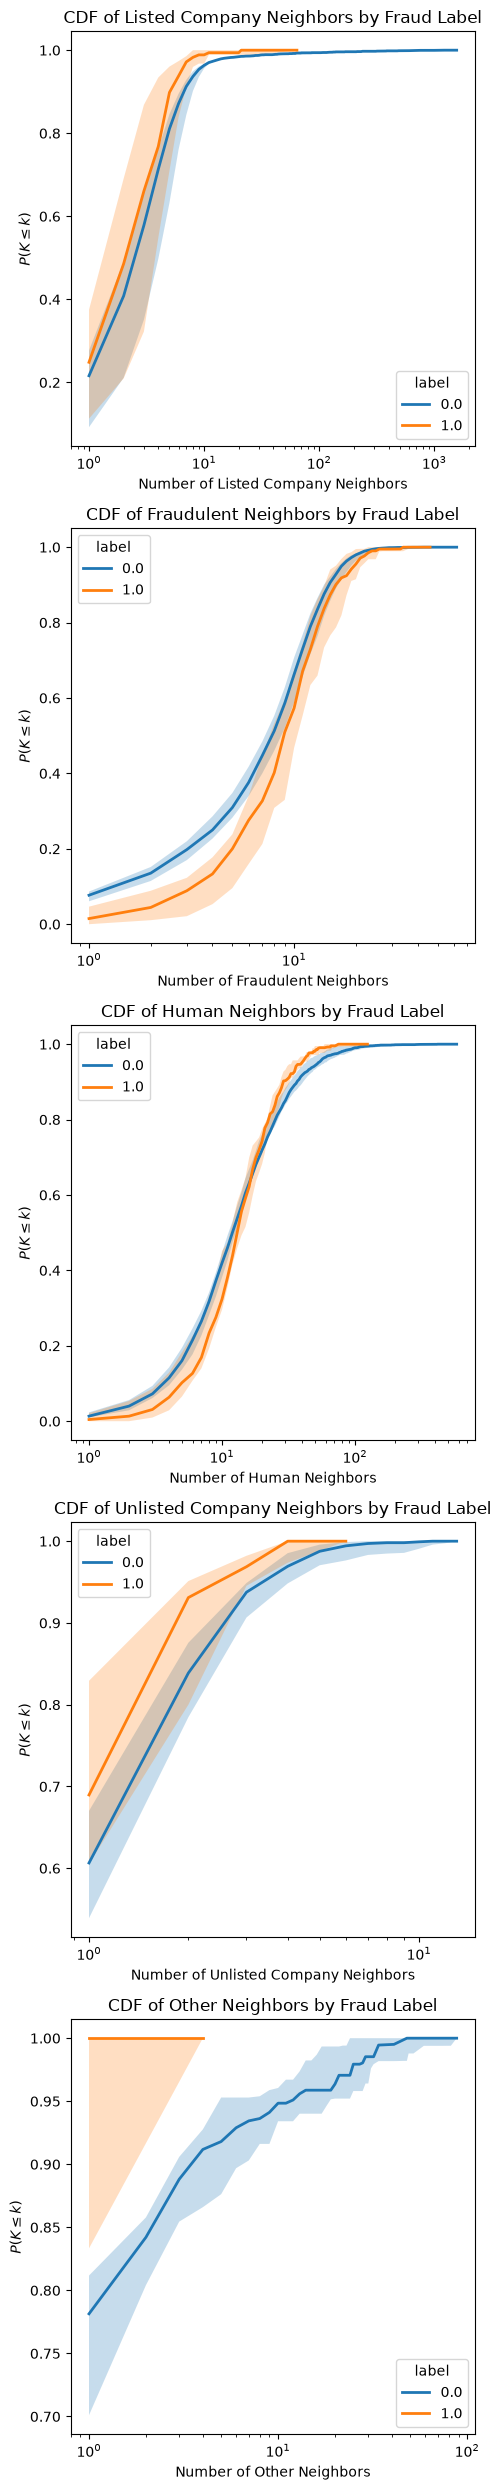

In [26]:
fig, axs = plt.subplots(5, 1, figsize=(5, 25))
cdf_plot(
    nodes_df.loc[lambda x: x["type"] == "L"],
    column="n_nb_L",
    group_by="label",
    ax=axs[0],
    xscale="log",
)
axs[0].set_title("CDF of Listed Company Neighbors by Fraud Label")
axs[0].set_xlabel("Number of Listed Company Neighbors")


cdf_plot(
    nodes_df.loc[lambda x: x["type"] == "L"],
    column="n_nb_fraud",
    group_by="label",
    ax=axs[4],
    xscale="log",
)
axs[1].set_title("CDF of Fraudulent Neighbors by Fraud Label")
axs[1].set_xlabel("Number of Fraudulent Neighbors")

cdf_plot(
    nodes_df.loc[lambda x: x["type"] == "L"],
    column="n_nb_H",
    group_by="label",
    ax=axs[1],
    xscale="log",
)
axs[2].set_title("CDF of Human Neighbors by Fraud Label")
axs[2].set_xlabel("Number of Human Neighbors")

cdf_plot(
    nodes_df.loc[lambda x: x["type"] == "L"],
    column="n_nb_U",
    group_by="label",
    ax=axs[2],
    xscale="log",
)
axs[3].set_title("CDF of Unlisted Company Neighbors by Fraud Label")
axs[3].set_xlabel("Number of Unlisted Company Neighbors")


cdf_plot(
    nodes_df.loc[lambda x: x["type"] == "L"],
    column="n_nb_O",
    group_by="label",
    ax=axs[3],
    xscale="log",
)
axs[4].set_title("CDF of Other Neighbors by Fraud Label")
axs[4].set_xlabel("Number of Other Neighbors")


plt.tight_layout()
plt.show()

Fradulent companies have **more listed companies**, **less fraudulent**, **more other** neighbors and **less humans** in their neighborhood than non-fraudulent companies, while the number of **unlisted companies** in their neighborhood is **similar**.

# Edges

*Please note: Some of the sections below aggregate data across all years; these are marked accordingly.*

## Edge Types (Pooled)

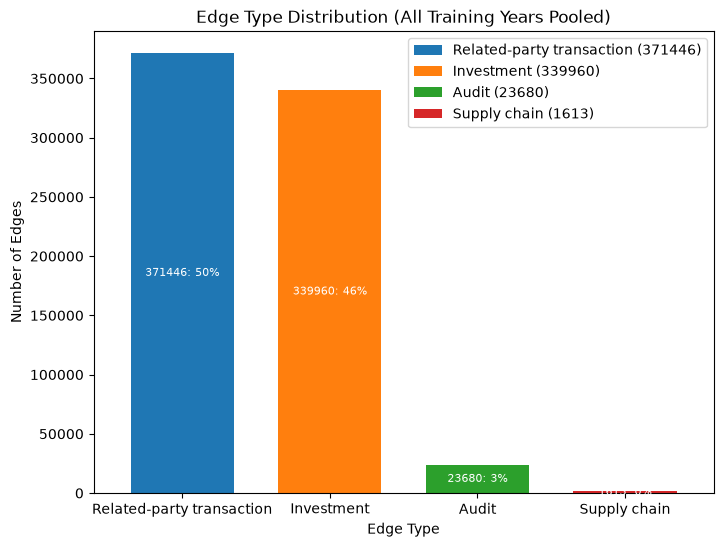

In [27]:
edge_type_value_cnt = train_edges["type"].value_counts()

draw_count_bar_plot(
    edge_type_value_cnt,
    xlabel="Edge Type",
    ylabel="Number of Edges",
    title="Edge Type Distribution (All Training Years Pooled)",
    legend_dict={
        "Audit": f"Audit ({edge_type_value_cnt.get('Audit')})",
        "Investment": f"Investment ({edge_type_value_cnt.get('Investment')})",
        "Related-party transaction": f"Related-party transaction ({edge_type_value_cnt.get('Related-party transaction')})",
        "Supply chain": f"Supply chain ({edge_type_value_cnt.get('Supply chain')})",
    },
)

**Related-party transaction** and **Investment** dominate the graph, together accounting for roughly **97%** of all edges.
**Audit** edges make up about **3%**, and **Supply chain** edges are the rarest at **under** **1%**.

### Edge Counts by Type and Node Type Pair (Pooled)

In [28]:
train_edges.value_counts(
    subset=["type", "node_type_1", "node_type_2"],
).reset_index().assign(
    percentage=lambda x: x["count"] / len(train_edges) * 100,
).sort_values(by="percentage", ascending=False).round(2)

,type,node_type_1,node_type_2,count,percentage
0,Related-party transaction,L,U,314478,42.69
1,Investment,L,H,154298,20.94
2,Investment,L,U,120522,16.36
3,Investment,L,L,51977,7.06
4,Related-party transaction,L,H,49429,6.71
5,Audit,L,A,23680,3.21
6,Investment,L,O,13163,1.79
7,Related-party transaction,L,L,6947,0.94
8,Supply chain,L,L,1613,0.22
9,Related-party transaction,L,O,592,0.08


### Edge Count by Node Type Pair (Pooled)

In [29]:
train_edges.value_counts(subset=["node_type_1", "node_type_2"]).reset_index().assign(
    percentage=lambda x: x["count"] / len(train_edges) * 100,
).sort_values(by="percentage", ascending=False).round(2)

,node_type_1,node_type_2,count,percentage
0,L,U,435000,59.05
1,L,H,203727,27.65
2,L,L,60537,8.22
3,L,A,23680,3.21
4,L,O,13755,1.87


The most common node type pair is **L <-> U** (Listed Company and Unlisted Company), which accounts for **~60%** of all edges followed by **L <-> H** (Listed Company and Human) at **~30%** and **L <-> L** (Listed Company and Listed Company) at **~10%**.

# Graph Homophily

The following section uses permutation test to score the homophily of the graph.

Parameters:
* `n_permutations` - number of permutations to use in the permutation test, since this is exploratory analysis, a smaller number of permutations is used to speed up the calculation.
* `method` - method to use for calculating homophily scores, one of `node`, `edge`, `edge_insensitive`.

In [ ]:
n_permutations = 100
method = "edge_insensitive"

print("Calculating homophily scores. This may take some time...")

homophily_df = compute_homophily_scores(
    train_tabular,
    train_edges,
    TRAIN_YEARS,
    method=method,
    nperm=n_permutations,
)

display(homophily_df.head(10))

In [31]:
homophily_df.groupby(["edge_name"]).agg(
    num_edges_min=("num_edges", "min"),
    num_edges_max=("num_edges", "max"),
    excess_h_min=("excess_h", "min"),
    excess_h_max=("excess_h", "max"),
    excess_h_z_score_min=("excess_h_z_score", "min"),
    excess_h_z_score_max=("excess_h_z_score", "max"),
    p_min=("p", "min"),
    p_max=("p", "max"),
).sort_values("excess_h_min").round(2)

,num_edges_min,num_edges_max,excess_h_min,excess_h_max,excess_h_z_score_min,excess_h_z_score_max,p_min,p_max
edge_name,,,,,,,,
"[('L', 'Related-party transaction', 'O'), ('O', 'Investment', 'L')]",48,515,-0.11,-0.01,-0.51,-0.08,0.22,1.00
"[('L', 'Related-party transaction', 'O'), ('O', 'Related-party transaction', 'L')]",0,20,-0.04,0.03,-1.73,0.67,0.39,1.00
"[('L', 'Investment', 'O'), ('O', 'Related-party transaction', 'L')]",48,515,-0.02,0.27,-0.18,5.95,0.02,0.49
"('L', 'Supply chain', 'L')",424,500,-0.02,0.10,-0.64,2.58,0.05,1.00
"[('L', 'Investment', 'H'), ('H', 'Related-party transaction', 'L')]",1602,9177,-0.02,0.08,-0.90,1.34,0.14,1.00
"[('L', 'Related-party transaction', 'H'), ('H', 'Investment', 'L')]",1602,9177,-0.01,0.05,-0.87,4.01,0.01,1.00
"[('L', 'Related-party transaction', 'U'), ('U', 'Investment', 'L')]",2239,7629,-0.01,0.01,-0.46,0.51,0.09,0.69
"[('L', 'Investment', 'U'), ('U', 'Related-party transaction', 'L')]",2239,7629,-0.01,0.06,-0.82,5.94,0.01,1.00
"('L', 'Related-party transaction', 'L')",1166,3076,-0.01,0.07,-0.27,4.41,0.01,0.42


The graph does **not show strong homophily**, as the excess homophily scores are close to zero for all edge types.